# High-fidelity diffraction module — `abtem_diffraction`

A **complete, reusable module** that adds *dynamical* (multislice) diffraction to the STEM
digital twin, built on **abTEM**. It is the high-fidelity path of the two-path design:

- The twin's built-in engine stays the **fast, interactive default** — kinematical,
  correct spot *positions*, ~seconds/frame, no heavy dependencies.
- This module is the **high-fidelity, offline** path — correct spot *intensities*,
  thickness effects, and (with frozen phonons) the thermal-diffuse background, so the
  simulated patterns can be analysed by external tools (py4DSTEM, strain/orientation
  mappers, ptychography) as if they were **real** data.

It ingests atoms from **any** twin sample through the shared
`get_atoms_in_region(...)` interface, or builds common crystals directly with ASE, and
exposes one clean API: `saed`, `cbed`, `scan_4d`, a beam-stop-aware `show`, plus helpers
(`build_crystal`, `atoms_from_twin_sample`, `tilted_atoms`, `save_4d`).

> CPU is fine at the sizes here (seconds per pattern). A GPU only matters for large 4D
> scans — `abtem.config.set({"device": "gpu"})`. This notebook is standalone; it does not
> need the twin server running.


## 0. Install (CPU) — no version conflicts

Only **abTEM + ASE** are needed, which are compatible with Colab's NumPy 2.x — no
downgrade, no runtime restart. (Do *not* also install py4DSTEM here; it pins `numpy<2` and
would force a downgrade. Use it in a separate, isolated step if you want it — see the note
at the end.)

In [1]:
!pip -q install abtem ase
import abtem, ase, numpy as np, matplotlib.pyplot as plt
print("abtem", abtem.__version__, "| ase", ase.__version__, "| numpy", np.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.7 MB/s eta 0:00:00
abtem 1.0.10 | ase 3.29.0 | numpy 2.0.2


## 1. The module

Written to `abtem_diffraction.py` so you can `import abtem_diffraction` from the twin or
any script. In the integrated project this file sits next to `stem_client.py`,
`microscope_backend.py`, etc.

In [2]:
%%writefile abtem_diffraction.py
"""
abtem_diffraction.py

High-fidelity (dynamical, multislice) diffraction engine for the STEM digital twin.

This is the *high-fidelity path* of the two-path design: the twin's built-in
kinematical engine stays the fast, interactive default (correct spot positions,
~seconds/frame, no heavy deps); this module computes *dynamical* diffraction with
abTEM multislice — correct spot intensities, thickness effects, and (with frozen
phonons) the thermal-diffuse background — so simulated patterns can be analysed by
external tools (py4DSTEM, strain/orientation mappers, ptychography) as if they were
real data. It is meant to be run offline to *generate* analysis-grade datasets, not
on the interactive acquisition loop.

It ingests atoms from ANY twin sample through the shared
`get_atoms_in_region(cx_um, cy_um, half_width_um, depth_nm) -> (positions_A, Z)`
interface, or builds common crystals directly with ASE.

Requires: abtem, ase  (CPU is fine; a GPU helps only for large 4D scans —
set abtem.config.set({"device": "gpu"}) if available).

Public API (see the class docstring for details):
    eng = AbtemDiffraction(energy_kev=200)
    atoms = AbtemDiffraction.build_crystal("Au", "fcc", 4.05, size=(6, 6, 20))
    atoms = eng.atoms_from_twin_sample(sample, half_width_um=0.02, depth_nm=12)
    dp    = eng.saed(atoms, num_frozen_phonons=8)          # plane-wave SAED
    cbed  = eng.cbed(atoms, convergence_mrad=8)            # single CBED pattern
    data4d, meta = eng.scan_4d(atoms, convergence_mrad=8)  # 4D-STEM stack
    AbtemDiffraction.show(ax, dp)                          # display w/ beam stop
"""
from __future__ import annotations
import numpy as np

try:
    import abtem
    from ase import Atoms
    from ase.build import bulk
except Exception as exc:  # pragma: no cover
    raise ImportError(
        "abtem_diffraction requires `abtem` and `ase` "
        "(`pip install abtem ase`)."
    ) from exc


class AbtemDiffraction:
    """Dynamical diffraction engine built on abTEM multislice.

    Parameters
    ----------
    energy_kev : float
        Accelerating voltage in kV (default 200).
    potential_sampling : float
        Real-space sampling of the projected potential, in Angstrom (default 0.08).
        Smaller = finer reciprocal-space coverage but slower.
    slice_thickness : float
        Multislice slice thickness in Angstrom (default 2.0).
    parametrization : str
        Scattering-factor parametrization for abTEM (default "lobato").
    device : str or None
        "cpu" (default) or "gpu" (needs CuPy). None uses the abTEM default.
    """

    def __init__(self, energy_kev: float = 200.0, potential_sampling: float = 0.08,
                 slice_thickness: float = 2.0, parametrization: str = "lobato",
                 device: str | None = "cpu"):
        self.energy_ev = float(energy_kev) * 1e3
        self.sampling = float(potential_sampling)
        self.slice_thickness = float(slice_thickness)
        self.parametrization = parametrization
        self.device = device

    # ------------------------------------------------------------------ #
    # Structure building / ingestion
    # ------------------------------------------------------------------ #
    @staticmethod
    def build_crystal(element: str, structure: str, a: float,
                      size: tuple = (6, 6, 20), c: float | None = None) -> Atoms:
        """Build a periodic crystal supercell with ASE (best diffraction quality,
        because the cell is inherently periodic).

        element : chemical symbol, e.g. "Au".
        structure : ASE structure, e.g. "fcc", "bcc", "hcp", "diamond", "sc".
        a : lattice constant in Angstrom (c optional for hcp).
        size : (nx, ny, nz) repetitions. nz sets the specimen thickness.
        """
        kw = dict(name=element, crystalstructure=structure, a=float(a), cubic=True)
        if c is not None:
            kw["c"] = float(c)
            kw.pop("cubic", None)   # hcp/tetragonal aren't 'cubic'
        try:
            cell = bulk(**kw)
        except Exception:
            kw.pop("cubic", None)
            cell = bulk(**kw)
        return cell * tuple(int(s) for s in size)

    def atoms_from_twin_sample(self, sample, half_width_um: float = 0.02,
                               depth_nm: float = 12.0, cx_um: float = 0.0,
                               cy_um: float = 0.0, generate_volume: bool = True,
                               vol_shape: tuple = (40, 256, 256),
                               max_lateral_A: float | None = 60.0,
                               max_thickness_A: float | None = 120.0) -> Atoms:
        """Pull atoms from a twin sample via its `get_atoms_in_region` interface and
        wrap them as an ASE `Atoms` with a periodic bounding box.

        Note: a bounding box around an arbitrary chunk of a crystal is not perfectly
        periodic at its faces, which can add weak artifacts. For a *clean* crystal
        pattern prefer `build_crystal`; use this when you specifically want the
        diffraction of the twin's actual modeled object (a defect, a grain, an
        Atomsk cell). Larger regions reduce the relative edge effect.

        Performance: the twin sizes its regions for its own (fast) kinematical
        engine and can return ~100k atoms in a ~110 A cube — multislice on that is
        slow (tens of seconds). `max_lateral_A` and `max_thickness_A` crop the
        returned atoms to a tractable box centred on the region (set either to None
        to disable). Cropping keeps the crystal periodicity essentially intact for a
        single crystal and makes runtime comparable to `build_crystal`.
        """
        if generate_volume and hasattr(sample, "generate_volume"):
            try:
                sample.generate_volume(*vol_shape)
            except Exception:
                pass
        positions_A, Z = sample.get_atoms_in_region(cx_um, cy_um, half_width_um, depth_nm)
        positions_A = np.asarray(positions_A, dtype=float)
        Z = np.asarray(Z, dtype=int)
        if positions_A.size == 0:
            raise ValueError("sample.get_atoms_in_region returned no atoms.")

        # Optionally crop to a tractable box centred on the atom cloud.
        centre = 0.5 * (positions_A.max(axis=0) + positions_A.min(axis=0))
        keep = np.ones(len(positions_A), dtype=bool)
        if max_lateral_A is not None:
            half = float(max_lateral_A) / 2.0
            keep &= np.abs(positions_A[:, 0] - centre[0]) <= half
            keep &= np.abs(positions_A[:, 1] - centre[1]) <= half
        if max_thickness_A is not None:
            halfz = float(max_thickness_A) / 2.0
            keep &= np.abs(positions_A[:, 2] - centre[2]) <= halfz
        positions_A = positions_A[keep]
        Z = Z[keep]
        if positions_A.size == 0:
            raise ValueError("cropping removed all atoms; increase max_lateral_A/max_thickness_A.")

        origin = positions_A.min(axis=0)
        positions_A = positions_A - origin
        extent = positions_A.max(axis=0)
        extent = np.where(extent > 1e-6, extent, 1.0) + 0.5
        return Atoms(numbers=Z, positions=positions_A, cell=extent.tolist(), pbc=True)

    # ------------------------------------------------------------------ #
    # Internal helpers
    # ------------------------------------------------------------------ #
    def _potential(self, atoms):
        return abtem.Potential(atoms, sampling=self.sampling,
                               slice_thickness=self.slice_thickness,
                               projection="infinite",
                               parametrization=self.parametrization,
                               device=self.device)

    def _potential_frozen(self, atoms, num_configs, sigmas):
        fp = abtem.FrozenPhonons(atoms, num_configs=int(num_configs),
                                 sigmas=float(sigmas), seed=1)
        return abtem.Potential(fp, sampling=self.sampling,
                               slice_thickness=self.slice_thickness,
                               projection="infinite",
                               parametrization=self.parametrization,
                               device=self.device)

    # ------------------------------------------------------------------ #
    # Diffraction modes
    # ------------------------------------------------------------------ #
    def saed(self, atoms, tilt_mrad: tuple = (0.0, 0.0), num_frozen_phonons: int = 0,
             sigmas: float = 0.1, max_angle_mrad: float = 60.0) -> np.ndarray:
        """Selected-area (plane-wave) diffraction pattern -> sharp spots.

        tilt_mrad : small beam tilt (mrad) for fine zone-axis alignment. For large
            zone-axis changes, rotate `atoms` instead (see `tilted_atoms`).
        num_frozen_phonons : 0 = single static config (fast). >0 averages that many
            frozen-phonon configurations to include thermal-diffuse scattering.
        Returns a 2D intensity array (the full pattern, direct beam included).
        """
        wave = abtem.PlaneWave(energy=self.energy_ev, sampling=self.sampling,
                               tilt=tuple(tilt_mrad), device=self.device)
        if num_frozen_phonons and num_frozen_phonons > 0:
            pot = self._potential_frozen(atoms, num_frozen_phonons, sigmas)
            dp = (wave.multislice(pot)
                      .diffraction_patterns(max_angle=max_angle_mrad)
                      .mean(0).compute())
        else:
            pot = self._potential(atoms)
            dp = (wave.multislice(pot)
                      .diffraction_patterns(max_angle=max_angle_mrad)
                      .compute())
        return np.asarray(dp.array, dtype=np.float32)

    def cbed(self, atoms, convergence_mrad: float = 8.0, tilt_mrad: tuple = (0.0, 0.0),
             num_frozen_phonons: int = 0, sigmas: float = 0.1,
             max_angle_mrad: float = 50.0) -> np.ndarray:
        """Convergent-beam diffraction pattern at a single (central) probe position.

        Each reflection becomes a DISK the size of `convergence_mrad`. If the
        convergence exceeds the spot spacing the disks overlap (Ronchigram /
        ptychography regime). Returns a 2D intensity array.
        """
        probe = abtem.Probe(energy=self.energy_ev, semiangle_cutoff=convergence_mrad,
                            sampling=self.sampling, tilt=tuple(tilt_mrad),
                            device=self.device)
        pot = (self._potential_frozen(atoms, num_frozen_phonons, sigmas)
               if num_frozen_phonons and num_frozen_phonons > 0 else self._potential(atoms))
        probe.grid.match(pot)
        det = abtem.PixelatedDetector(max_angle=max_angle_mrad)
        if num_frozen_phonons and num_frozen_phonons > 0:
            meas = probe.multislice(pot, detectors=det).mean(0).compute()
        else:
            meas = probe.multislice(pot, detectors=det).compute()
        return np.asarray(meas.array, dtype=np.float32)

    def scan_4d(self, atoms, convergence_mrad: float = 8.0, scan_gpts: tuple = (6, 6),
                scan_extent_A: float | tuple | None = None, max_angle_mrad: float = 50.0):
        """4D-STEM scan: a CBED pattern at every probe position.

        Returns (data_4d, meta) where data_4d has shape
        (scan_y, scan_x, det_y, det_x) and meta is a dict with the scan/probe params.
        The 4D array is what py4DSTEM's DataCube wraps directly.

        scan_extent_A : side length (or (x, y)) of the scanned region in Angstrom.
            Defaults to ~2 lattice-ish (a small representative patch). Kept modest
            because cost scales with the number of probe positions.
        """
        probe = abtem.Probe(energy=self.energy_ev, semiangle_cutoff=convergence_mrad,
                            sampling=self.sampling, device=self.device)
        pot = self._potential(atoms)
        probe.grid.match(pot)

        cell_xy = np.array(atoms.cell.lengths()[:2])
        if scan_extent_A is None:
            ext = np.minimum(cell_xy * 0.8, np.array([8.0, 8.0]))  # small patch, within cell
        elif np.isscalar(scan_extent_A):
            ext = np.array([float(scan_extent_A), float(scan_extent_A)])
        else:
            ext = np.array(scan_extent_A, dtype=float)

        scan = abtem.GridScan(start=(0.0, 0.0), end=(float(ext[0]), float(ext[1])),
                              gpts=tuple(int(g) for g in scan_gpts))
        det = abtem.PixelatedDetector(max_angle=max_angle_mrad)
        dataset = probe.scan(pot, scan=scan, detectors=det).compute()
        data_4d = np.asarray(dataset.array, dtype=np.float32)
        meta = {"convergence_mrad": float(convergence_mrad),
                "scan_gpts": tuple(int(g) for g in scan_gpts),
                "scan_extent_A": ext.tolist(),
                "energy_kev": self.energy_ev / 1e3,
                "max_angle_mrad": float(max_angle_mrad),
                "shape": data_4d.shape}
        return data_4d, meta

    # ------------------------------------------------------------------ #
    # Utilities
    # ------------------------------------------------------------------ #
    @staticmethod
    def tilted_atoms(atoms, tilt_deg_x: float = 0.0, tilt_deg_y: float = 0.0) -> Atoms:
        """Return a copy of `atoms` rotated for a LARGE zone-axis change (degrees).

        For big tilts, rotating the structure is more correct than a small beam
        tilt. Note: after rotation the periodic cell is only approximate at the
        faces; use a thick enough slab that the region of interest is interior.
        """
        a = atoms.copy()
        if tilt_deg_x:
            a.rotate(tilt_deg_x, "x", rotate_cell=False)
        if tilt_deg_y:
            a.rotate(tilt_deg_y, "y", rotate_cell=False)
        # recentre into a fresh periodic box
        pos = a.get_positions()
        pos = pos - pos.min(axis=0)
        ext = pos.max(axis=0) + 0.5
        return Atoms(numbers=a.get_atomic_numbers(), positions=pos, cell=ext.tolist(), pbc=True)

    @staticmethod
    def save_4d(data_4d: np.ndarray, path: str) -> str:
        """Save a 4D-STEM stack as .npy (py4DSTEM.DataCube(data=np.load(path)))."""
        np.save(path, np.asarray(data_4d, dtype=np.float32))
        return path

    @staticmethod
    def show(ax, pattern, beamstop_radius: int = 6, cmap: str = "inferno",
             title: str | None = None, log: bool = False):
        """Display a diffraction pattern with the DIRECT (000) beam suppressed.

        The undiffracted beam is ~100x brighter than the Bragg spots, so a naive
        display shows only the central dot. We clip the display maximum to the
        Bragg level (a computational beam stop) so the spots are visible. This
        changes only the display, not the data. Set log=True for extra compression.
        """
        p = np.asarray(pattern, dtype=float)
        cy, cx = np.unravel_index(np.argmax(p), p.shape)
        Y, X = np.mgrid[0:p.shape[0], 0:p.shape[1]]
        outside = np.hypot(Y - cy, X - cx) > beamstop_radius
        img = np.log1p(p) if log else p
        vmax = np.percentile(img[outside], 99.9) if outside.any() else img.max()
        vmax = max(float(vmax), 1e-12)
        ax.imshow(img, cmap=cmap, vmax=vmax)
        ax.axis("off")
        if title:
            ax.set_title(title)


Writing abtem_diffraction.py


In [3]:
import importlib, abtem_diffraction
importlib.reload(abtem_diffraction)
from abtem_diffraction import AbtemDiffraction
print("public API:", [m for m in dir(AbtemDiffraction) if not m.startswith('_')])
eng = AbtemDiffraction(energy_kev=200)   # one engine, reused below


public API: ['atoms_from_twin_sample', 'build_crystal', 'cbed', 'saed', 'save_4d', 'scan_4d', 'show', 'tilted_atoms']


## 2. SAED — selected-area (plane-wave) diffraction

Build an FCC Au crystal and take a dynamical SAED pattern. The bright centre is the direct
(undiffracted) beam — `AbtemDiffraction.show` clips it (a computational beam stop) so the
Bragg spots are visible. The intensities here are *dynamical*, unlike the kinematical
engine.

2880 atoms, cell [24.3 24.3 81. ] A


tasks:  75%|#######5  | 3/4 [00:05<00:01,  1.77s/it]

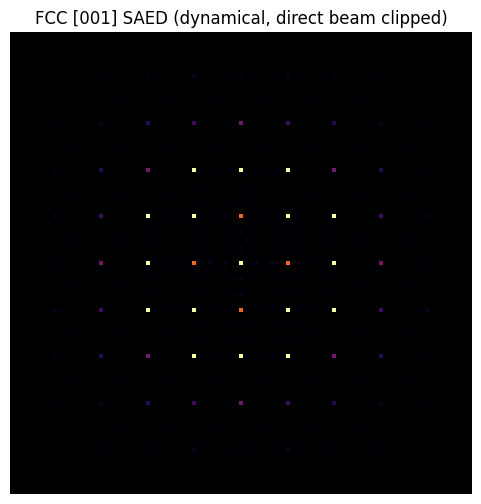

Inner 4 spots = {200}; diagonal = {220}.


In [4]:
atoms = AbtemDiffraction.build_crystal("Au", "fcc", 4.05, size=(6, 6, 20))
print(f"{len(atoms)} atoms, cell {np.round(atoms.cell.lengths(),1)} A")

dp = eng.saed(atoms)                              # static (single config)
fig, ax = plt.subplots(figsize=(6, 6))
AbtemDiffraction.show(ax, dp, title="FCC [001] SAED (dynamical, direct beam clipped)")
plt.show()
print("Inner 4 spots = {200}; diagonal = {220}.")


## 3. Frozen phonons — thermal-diffuse background

`num_frozen_phonons > 0` averages that many displaced-atom configurations, adding the
diffuse background that real patterns have (and that analysis tools expect). A few configs
suffice for CPU; real work uses 16–32.

tasks:  75%|#######5  | 3/4 [00:02<00:00,  1.09it/s]

tasks:  21%|##        | 5/24 [00:03<00:13,  1.41it/s]

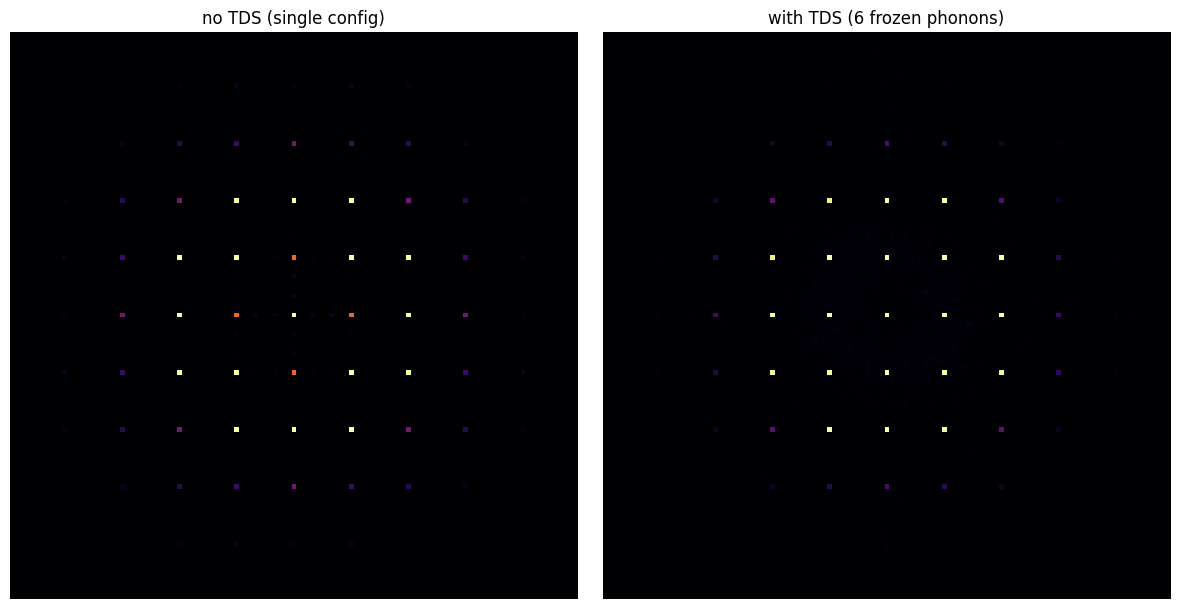

With TDS: diffuse background between spots + redistributed intensity.


In [5]:
dp_static = eng.saed(atoms, num_frozen_phonons=0)
dp_tds     = eng.saed(atoms, num_frozen_phonons=6)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
AbtemDiffraction.show(axs[0], dp_static, title="no TDS (single config)")
AbtemDiffraction.show(axs[1], dp_tds,    title="with TDS (6 frozen phonons)")
plt.tight_layout(); plt.show()
print("With TDS: diffuse background between spots + redistributed intensity.")


## 4. CBED — convergent-beam diffraction

A focused probe turns each reflection into a *disk* the size of the convergence angle.
Small convergence → separated disks; large convergence → overlapping disks (Ronchigram /
ptychography regime). For FCC Au the disks are ~10–12 mrad apart, so 8 mrad keeps them
separated.

tasks:  83%|########3 | 5/6 [00:00<00:00,  5.07it/s]

tasks:  83%|########3 | 5/6 [00:00<00:00,  5.04it/s]

tasks:  83%|########3 | 5/6 [00:00<00:00,  5.14it/s]

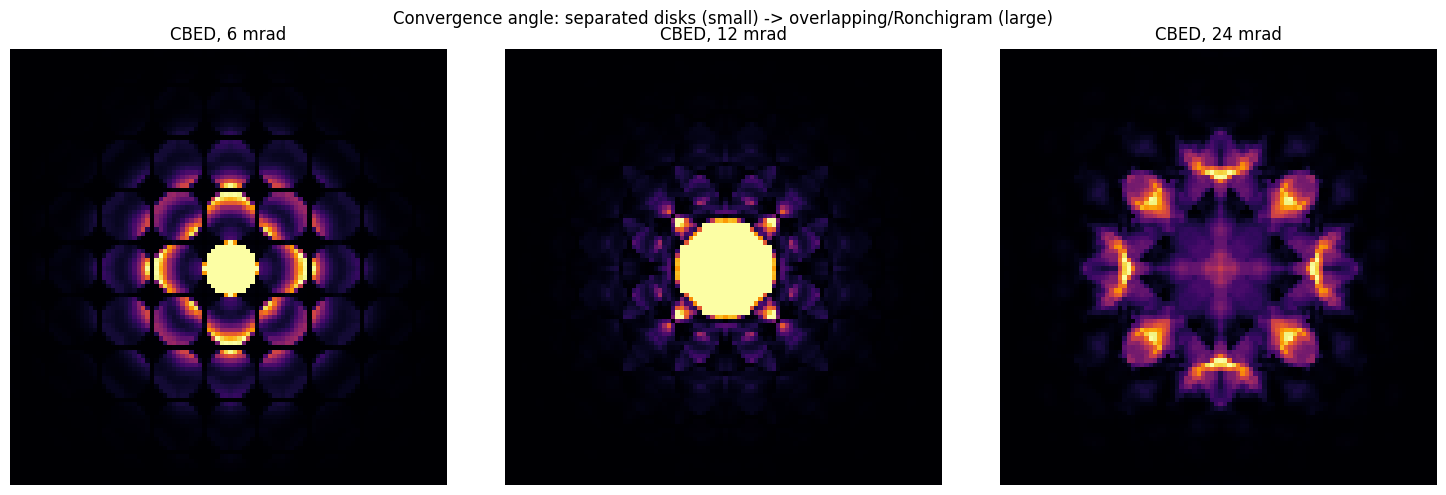

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, conv in zip(axs, [6, 12, 24]):
    cb = eng.cbed(atoms, convergence_mrad=conv)
    AbtemDiffraction.show(ax, cb, beamstop_radius=int(conv*1.2), title=f"CBED, {conv} mrad")
plt.suptitle("Convergence angle: separated disks (small) -> overlapping/Ronchigram (large)")
plt.tight_layout(); plt.show()


## 5. 4D-STEM scan → portable dataset

`scan_4d` records a CBED pattern at every probe position and returns a 4D array
`(scan_y, scan_x, det_y, det_x)` plus a metadata dict. Save it with `save_4d`; any analysis
tool (py4DSTEM's `DataCube`) opens it directly. Kept small for CPU.

tasks:  75%|#######5  | 3/4 [00:11<00:03,  3.98s/it]

4D shape: (6, 6, 100, 100) | meta: {'convergence_mrad': 8.0, 'scan_gpts': (6, 6), 'scan_extent_A': [8.0, 8.0], 'energy_kev': 200.0, 'max_angle_mrad': 50.0, 'shape': (6, 6, 100, 100)}


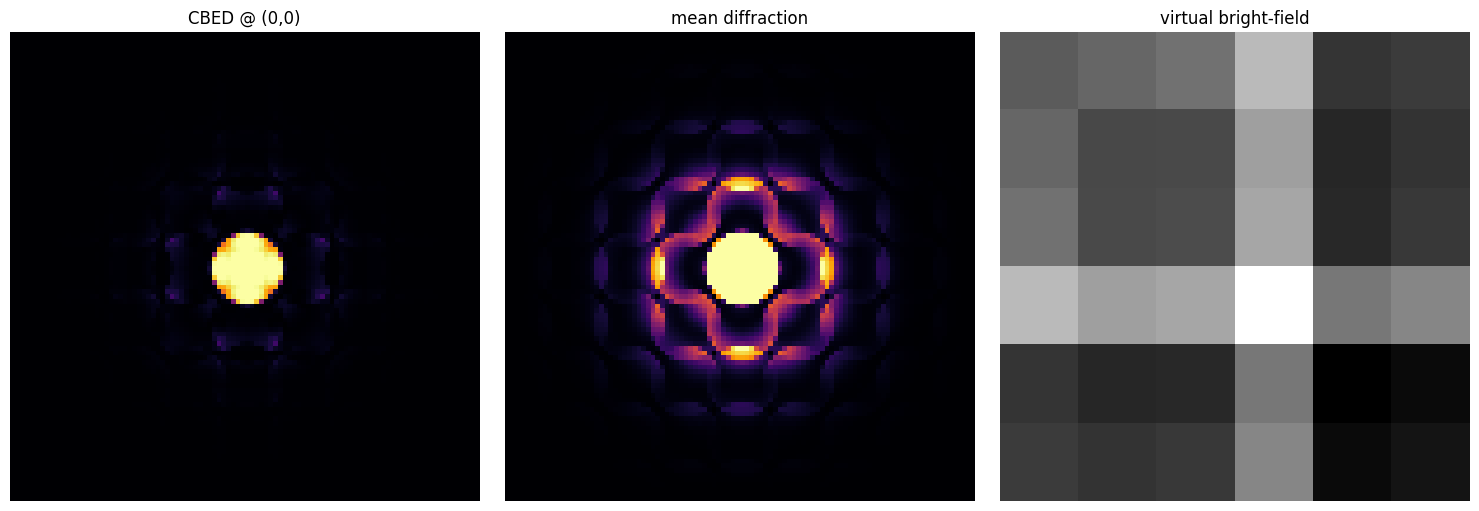

Saved fcc_4dstem.npy -> load elsewhere with py4DSTEM.DataCube(data=np.load(...)).


In [7]:
data_4d, meta = eng.scan_4d(atoms, convergence_mrad=8, scan_gpts=(6, 6))
print("4D shape:", data_4d.shape, "| meta:", meta)
AbtemDiffraction.save_4d(data_4d, "fcc_4dstem.npy")

# quick look at a few positions + a mean pattern + a virtual bright-field (plain numpy)
dp_mean = data_4d.mean(axis=(0, 1))
qy, qx = data_4d.shape[2] // 2, data_4d.shape[3] // 2
Y, X = np.mgrid[0:data_4d.shape[2], 0:data_4d.shape[3]]
bf = (data_4d * (np.hypot(Y-qy, X-qx) <= 8)[None, None]).sum(axis=(2, 3))

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
AbtemDiffraction.show(axs[0], data_4d[0, 0], beamstop_radius=10, title="CBED @ (0,0)")
AbtemDiffraction.show(axs[1], dp_mean, beamstop_radius=10, title="mean diffraction")
axs[2].imshow(bf, cmap="gray"); axs[2].set_title("virtual bright-field"); axs[2].axis("off")
plt.tight_layout(); plt.show()
print("Saved fcc_4dstem.npy -> load elsewhere with py4DSTEM.DataCube(data=np.load(...)).")


## 6. Different samples

**Route A — materials via ASE** (self-contained): one line each; different structures give
different diffraction symmetry.

tasks:  75%|#######5  | 3/4 [00:00<00:00,  3.52it/s]

tasks:  75%|#######5  | 3/4 [00:01<00:00,  1.53it/s]

tasks:  75%|#######5  | 3/4 [00:01<00:00,  2.28it/s]

tasks:  75%|#######5  | 3/4 [00:02<00:00,  1.27it/s]

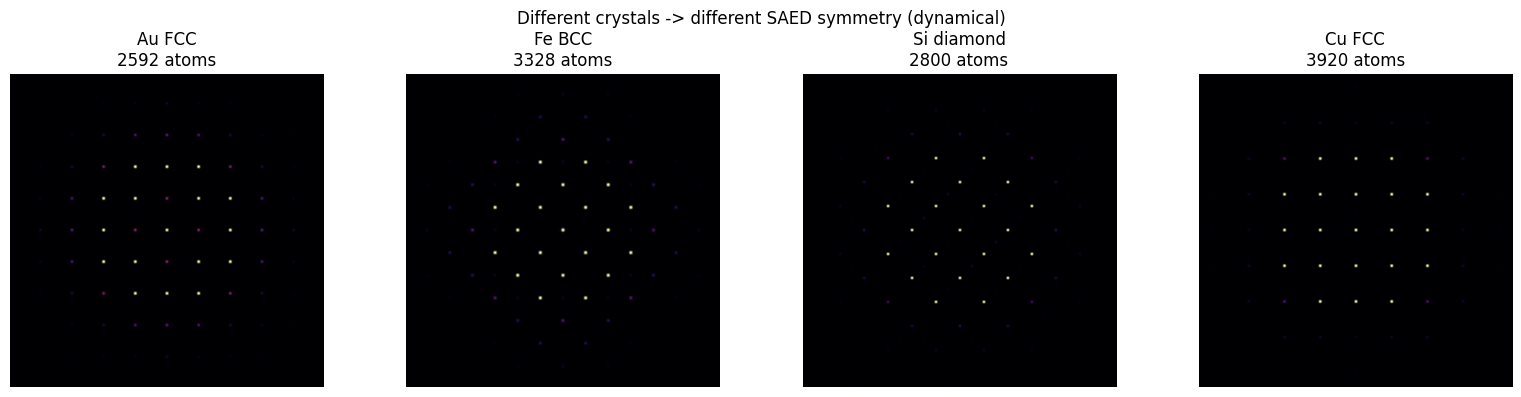

In [8]:
materials = [
    ("Au FCC",     ("Au", "fcc",     4.05, (6, 6, 18))),
    ("Fe BCC",     ("Fe", "bcc",     2.87, (8, 8, 26))),
    ("Si diamond", ("Si", "diamond", 5.43, (5, 5, 14))),
    ("Cu FCC",     ("Cu", "fcc",     3.61, (7, 7, 20))),
]
fig, axs = plt.subplots(1, len(materials), figsize=(4*len(materials), 4))
for ax, (name, (el, st, a, sz)) in zip(axs, materials):
    aa = AbtemDiffraction.build_crystal(el, st, a, size=sz)
    AbtemDiffraction.show(ax, eng.saed(aa), title=f"{name}\n{len(aa)} atoms")
plt.suptitle("Different crystals -> different SAED symmetry (dynamical)")
plt.tight_layout(); plt.show()


**Route B — the twin's *own* samples.** This is the integration point: any twin sample
hands back atoms via `get_atoms_in_region`, and `atoms_from_twin_sample` wraps them for the
same engine — so the dynamical pattern is of *your actual modeled object* (a defect, a
grain, an Atomsk cell), not a generic crystal.

The twin sizes its regions for its own fast kinematical engine and can return ~100k atoms;
`atoms_from_twin_sample` crops to a tractable box by default (`max_lateral_A`,
`max_thickness_A`) so multislice stays quick. Run this cell inside the twin environment
(the `samples` package must be importable).

In [9]:
# --- Route B: from the twin's own samples (needs the twin `samples` package) ---
try:
    import samples  # the twin's sample registry
    s = samples.get_sample("fcc_single_crystal")          # or bcc_single_crystal, dislocation_crystal, ...
    twin_atoms = eng.atoms_from_twin_sample(s, half_width_um=0.02, depth_nm=10,
                                            max_lateral_A=50, max_thickness_A=80)
    print(f"twin sample -> {len(twin_atoms)} atoms, cell {np.round(twin_atoms.cell.lengths(),1)} A")
    dp_twin = eng.saed(twin_atoms)
    fig, ax = plt.subplots(figsize=(6, 6))
    AbtemDiffraction.show(ax, dp_twin, title="dynamical SAED of the TWIN's FCC sample")
    plt.show()
except ModuleNotFoundError:
    print("`samples` package not on the path — run this inside the twin environment.")
    print("(Route A above is fully self-contained and does not need the twin.)")


`samples` package not on the path — run this inside the twin environment.
(Route A above is fully self-contained and does not need the twin.)


## Notes & limits

- **Fidelity ceiling is the structure, not the engine.** Multislice faithfully computes the
  diffraction of whatever atoms you give it — so for cases where the *object* must be right
  (a real dislocation core, a real strain field, texture), feed in an Atomsk/MD structure via
  the same `atoms` entry point. Add detector PSF/MTF and Poisson noise on top if your analyzer
  is sensitive to them (the twin already models dose).
- **Direct beam is kept in the data.** `show` only *displays* it clipped (beam stop); saved
  arrays contain the full pattern, which is what analysis tools need.
- **Large tilts:** `saed(..., tilt_mrad=...)` is small-angle (fine alignment). For big
  zone-axis changes use `tilted_atoms(atoms, tilt_deg_x=...)` (rotates the structure; the
  cell is then only approximately periodic at the faces — use a thick enough slab).
- **py4DSTEM round-trip:** load a saved `.npy` in a *separate, isolated* environment
  (`pip install py4dstem` downgrades NumPy to <2; restart the runtime), then
  `py4DSTEM.DataCube(data=np.load("fcc_4dstem.npy"))`.
- **GPU:** for full 128×128 scans with many phonon configs, set
  `abtem.config.set({"device": "gpu"})` (needs CuPy) — the cost is paid once at generation.
